In [ ]:
!pip install nibabel
!pip install scikit-image
!pip install pydensecrf
!pip install segmentation-models-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.1 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.5 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_956499e886a7fd943bf670f27674a87e"

In [ ]:
!pip install kaggle

In [ ]:
!kaggle competitions list

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
!kaggle datasets download mateuszbuda/lgg-mri-segmentation

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [ ]:
!kaggle datasets list -s brain tumor

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
import kagglehub

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Path to dataset files: /kaggle/input/lgg-mri-segmentation


In [ ]:
import os

dataset_path = "/kaggle/input/lgg-mri-segmentation"

os.listdir(dataset_path)

['kaggle_3m', 'lgg-mri-segmentation']

In [ ]:
import os

data_path = "/kaggle/input/lgg-mri-segmentation/kaggle_3m"

print(len(os.listdir(data_path)))
os.listdir(data_path)[:5]

112


['TCGA_DU_7010_19860307',
 'TCGA_DU_8162_19961029',
 'TCGA_FG_A4MT_20020212',
 'TCGA_FG_5964_20010511',
 'TCGA_DU_A5TS_19970726']

In [ ]:
import os

data_path = "/kaggle/input/lgg-mri-segmentation/kaggle_3m"

image_paths = []
mask_paths = []

for patient in os.listdir(data_path):

    patient_folder = os.path.join(data_path, patient)

    # skip files like README.md or data.csv
    if not os.path.isdir(patient_folder):
        continue

    for file in os.listdir(patient_folder):

        if file.endswith(".tif") and "mask" not in file:

            img = os.path.join(patient_folder, file)
            mask = os.path.join(patient_folder, file.replace(".tif","_mask.tif"))

            image_paths.append(img)
            mask_paths.append(mask)

print("Total MRI slices:", len(image_paths))

Total MRI slices: 3929


Text(0.5, 1.0, 'Tumor Mask')

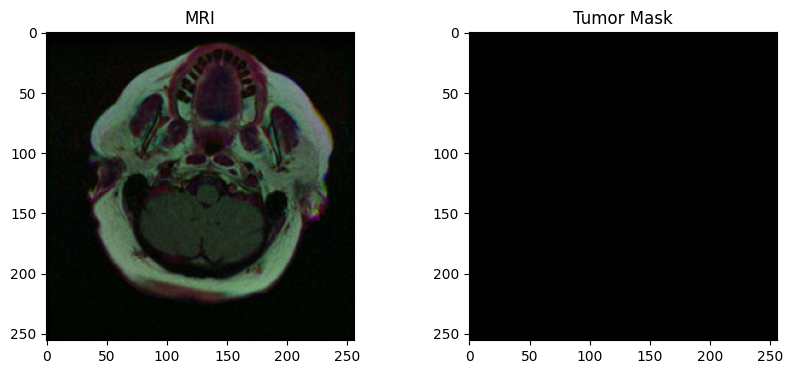

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_paths[10])
mask = cv2.imread(mask_paths[10],0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("MRI")

plt.subplot(1,2,2)
plt.imshow(mask,cmap="gray")
plt.title("Tumor Mask")

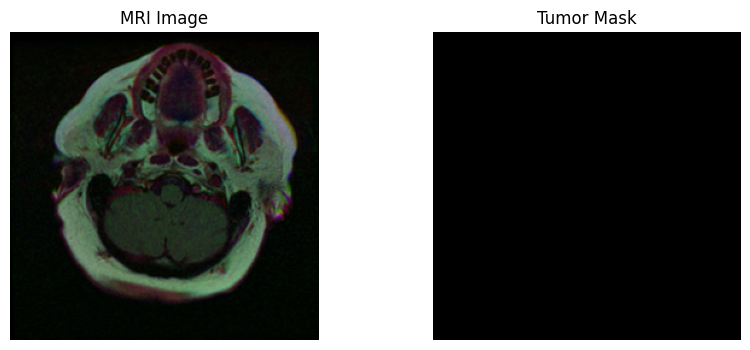

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_paths[10])
mask = cv2.imread(mask_paths[10],0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.show()

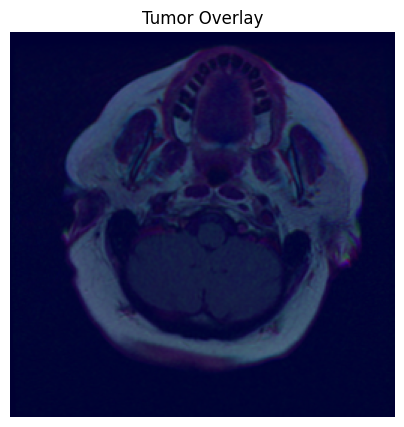

In [ ]:
plt.figure(figsize=(5,5))

plt.imshow(img)
plt.imshow(mask, cmap="jet", alpha=0.4)

plt.title("Tumor Overlay")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

print("Unique mask values:", np.unique(mask))
print("Tumor pixels:", np.sum(mask > 0))

Unique mask values: [0]
Tumor pixels: 0


In [ ]:
for i in range(len(mask_paths)):

    mask = cv2.imread(mask_paths[i],0)

    if mask.max() > 0:
        print("Tumor found at index:", i)
        break

Tumor found at index: 0


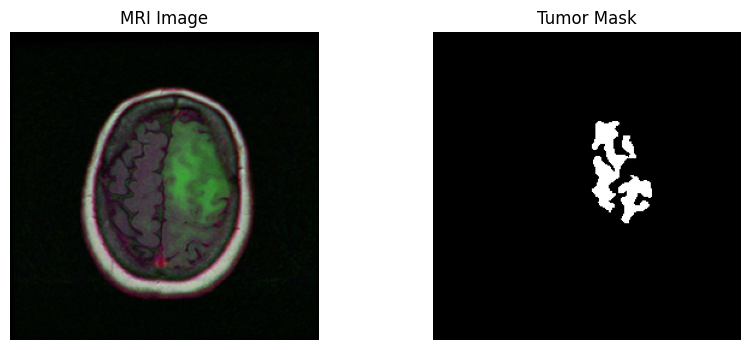

In [ ]:
idx = 0

img = cv2.imread(image_paths[idx])
mask = cv2.imread(mask_paths[idx], 0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=42
)

print("Train images:", len(train_imgs))
print("Validation images:", len(val_imgs))

Train images: 3143
Validation images: 786


In [ ]:
IMG_SIZE = 256

def preprocess(img_path, mask_path):

    img = cv2.imread(img_path,0)
    mask = cv2.imread(mask_path,0)

    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))

    img = img.astype("float32")
    img = (img - img.min()) / (img.max() - img.min())

    mask = mask / 255.0

    return img, mask

In [ ]:
import torch
from torch.utils.data import Dataset

class BrainDataset(Dataset):

    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img, mask = preprocess(self.images[idx], self.masks[idx])

        img = img[np.newaxis,:,:]

        return torch.tensor(img,dtype=torch.float32), torch.tensor(mask,dtype=torch.float32)

In [ ]:
from torch.utils.data import DataLoader

train_dataset = BrainDataset(train_imgs, train_masks)
val_dataset = BrainDataset(val_imgs, val_masks)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):

        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

In [ ]:
class PyramidPooling(nn.Module):

    def __init__(self, in_channels):

        super().__init__()

        self.pool1 = nn.AdaptiveAvgPool2d(1)
        self.pool2 = nn.AdaptiveAvgPool2d(2)
        self.pool3 = nn.AdaptiveAvgPool2d(3)
        self.pool4 = nn.AdaptiveAvgPool2d(6)

    def forward(self, x):

        size = x.size()[2:]

        p1 = F.interpolate(self.pool1(x), size=size, mode='bilinear', align_corners=False)
        p2 = F.interpolate(self.pool2(x), size=size, mode='bilinear', align_corners=False)
        p3 = F.interpolate(self.pool3(x), size=size, mode='bilinear', align_corners=False)
        p4 = F.interpolate(self.pool4(x), size=size, mode='bilinear', align_corners=False)

        return torch.cat([x, p1, p2, p3, p4], dim=1)

In [ ]:
class AttentionUNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder
        self.e1 = ConvBlock(1,64)
        self.e2 = ConvBlock(64,128)
        self.e3 = ConvBlock(128,256)
        self.e4 = ConvBlock(256,512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(512,1024)

        # Pyramid Pooling
        self.ppm = PyramidPooling(1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024*5,512,2,stride=2)
        self.att4 = AttentionBlock(512,512,256)
        self.d4 = ConvBlock(1024,512)

        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.att3 = AttentionBlock(256,256,128)
        self.d3 = ConvBlock(512,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.att2 = AttentionBlock(128,128,64)
        self.d2 = ConvBlock(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.att1 = AttentionBlock(64,64,32)
        self.d1 = ConvBlock(128,64)

        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):

        # Encoder
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Multi-scale
        b = self.ppm(b)

        # Decoder
        d4 = self.up4(b)
        e4 = self.att4(d4,e4)
        d4 = self.d4(torch.cat([d4,e4],dim=1))

        d3 = self.up3(d4)
        e3 = self.att3(d3,e3)
        d3 = self.d3(torch.cat([d3,e3],dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2,e2)
        d2 = self.d2(torch.cat([d2,e2],dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1,e1)
        d1 = self.d1(torch.cat([d1,e1],dim=1))

        return torch.sigmoid(self.out(d1))

In [ ]:
model = AttentionUNet().cuda()

In [ ]:
def dice_loss(pred,target):

    smooth = 1

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()

    return 1 - ((2.*intersection + smooth) /
               (pred.sum() + target.sum() + smooth))

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
for epoch in range(20):

    model.train()

    total_loss = 0

    for images, masks in train_loader:

        images = images.cuda()
        masks = masks.cuda()

        optimizer.zero_grad()

        outputs = model(images)

        loss = dice_loss(outputs, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:",epoch,"Loss:",total_loss/len(train_loader))

Epoch: 0 Loss: 0.9304781123882032
Epoch: 1 Loss: 0.8773979144241973
Epoch: 2 Loss: 0.7740218097927006
Epoch: 3 Loss: 0.6076701477587071
Epoch: 4 Loss: 0.49402589682707654
Epoch: 5 Loss: 0.42619858928612475
Epoch: 6 Loss: 0.41205706563008043
Epoch: 7 Loss: 0.3717344494266364
Epoch: 8 Loss: 0.362877838180872
Epoch: 9 Loss: 0.33152152533446255
Epoch: 10 Loss: 0.30977737054266696
Epoch: 11 Loss: 0.31282981919271646
Epoch: 12 Loss: 0.3284240463611127
Epoch: 13 Loss: 0.26958396371084314
Epoch: 14 Loss: 0.28878045855587675
Epoch: 15 Loss: 0.28052034329518716
Epoch: 16 Loss: 0.2678272981983408
Epoch: 17 Loss: 0.2594860193080271
Epoch: 18 Loss: 0.2510189254775302
Epoch: 19 Loss: 0.23462338438470856


In [ ]:
data_path = "/kaggle/input/lgg-mri-segmentation/kaggle_3m"

image_paths = []
mask_paths = []

for patient in os.listdir(data_path):

    patient_folder = os.path.join(data_path, patient)

    if not os.path.isdir(patient_folder):
        continue

    for file in os.listdir(patient_folder):

        if file.endswith(".tif") and "mask" not in file:

            img = os.path.join(patient_folder,file)
            mask = os.path.join(patient_folder,file.replace(".tif","_mask.tif"))

            image_paths.append(img)
            mask_paths.append(mask)

print("Total MRI slices:", len(image_paths))

Total MRI slices: 3929


In [ ]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=42
)

print(len(train_imgs), len(val_imgs))

3143 786


In [ ]:
class BrainDataset(Dataset):

    def __init__(self, images, masks):

        self.images = images
        self.masks = masks

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img, mask = preprocess(self.images[idx], self.masks[idx])

        img = np.expand_dims(img,0)
        mask = np.expand_dims(mask,0)

        img = torch.tensor(img,dtype=torch.float32)
        mask = torch.tensor(mask,dtype=torch.float32)

        return img, mask

In [ ]:
train_dataset = BrainDataset(train_imgs,train_masks)
val_dataset = BrainDataset(val_imgs,val_masks)

train_loader = DataLoader(train_dataset,batch_size=8,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=8)

In [ ]:
class ConvBlock(nn.Module):

    def __init__(self,in_ch,out_ch):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_ch,out_ch,3,padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch,out_ch,3,padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):

        return self.conv(x)

In [ ]:
class AttentionBlock(nn.Module):

    def __init__(self,F_g,F_l,F_int):

        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g,F_int,1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l,F_int,1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int,1,1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self,g,x):

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1+x1)
        psi = self.psi(psi)

        return x*psi

In [ ]:
class PyramidPooling(nn.Module):

    def __init__(self,in_channels):

        super().__init__()

        self.pool1 = nn.AdaptiveAvgPool2d(1)
        self.pool2 = nn.AdaptiveAvgPool2d(2)
        self.pool3 = nn.AdaptiveAvgPool2d(3)
        self.pool4 = nn.AdaptiveAvgPool2d(6)

    def forward(self,x):

        size = x.size()[2:]

        p1 = F.interpolate(self.pool1(x),size=size,mode="bilinear",align_corners=False)
        p2 = F.interpolate(self.pool2(x),size=size,mode="bilinear",align_corners=False)
        p3 = F.interpolate(self.pool3(x),size=size,mode="bilinear",align_corners=False)
        p4 = F.interpolate(self.pool4(x),size=size,mode="bilinear",align_corners=False)

        return torch.cat([x,p1,p2,p3,p4],dim=1)

In [ ]:
class AttentionUNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.e1 = ConvBlock(1,64)
        self.e2 = ConvBlock(64,128)
        self.e3 = ConvBlock(128,256)
        self.e4 = ConvBlock(256,512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(512,1024)

        self.ppm = PyramidPooling(1024)

        self.up4 = nn.ConvTranspose2d(1024*5,512,2,stride=2)
        self.att4 = AttentionBlock(512,512,256)
        self.d4 = ConvBlock(1024,512)

        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.att3 = AttentionBlock(256,256,128)
        self.d3 = ConvBlock(512,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.att2 = AttentionBlock(128,128,64)
        self.d2 = ConvBlock(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.att1 = AttentionBlock(64,64,32)
        self.d1 = ConvBlock(128,64)

        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):

        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        b = self.ppm(b)

        d4 = self.up4(b)
        e4 = self.att4(d4,e4)
        d4 = self.d4(torch.cat([d4,e4],dim=1))

        d3 = self.up3(d4)
        e3 = self.att3(d3,e3)
        d3 = self.d3(torch.cat([d3,e3],dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2,e2)
        d2 = self.d2(torch.cat([d2,e2],dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1,e1)
        d1 = self.d1(torch.cat([d1,e1],dim=1))

        return torch.sigmoid(self.out(d1))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNet().to(device)

In [ ]:
bce = nn.BCELoss()

def dice_loss(pred,target):

    smooth = 1

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred*target).sum()

    return 1 - ((2*intersection+smooth)/(pred.sum()+target.sum()+smooth))

def combined_loss(pred,target):

    return dice_loss(pred,target) + bce(pred,target)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)

In [ ]:
EPOCHS = 30

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for images,masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs,masks)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:",epoch,"Loss:",total_loss/len(train_loader))

Epoch: 0 Loss: 1.249359351381394
Epoch: 1 Loss: 1.055298831019996
Epoch: 2 Loss: 0.9179870935190119
Epoch: 3 Loss: 0.7668103952595903
Epoch: 4 Loss: 0.6114030589963341
Epoch: 5 Loss: 0.5149180405315855
Epoch: 6 Loss: 0.47093180684567104
Epoch: 7 Loss: 0.4139853104304418
Epoch: 8 Loss: 0.3937197207229131
Epoch: 9 Loss: 0.3973222683366322
Epoch: 10 Loss: 0.3634020399311723
Epoch: 11 Loss: 0.3396883712792366
Epoch: 12 Loss: 0.34928917843118573
Epoch: 13 Loss: 0.3279337069308788
Epoch: 14 Loss: 0.2991761279318472
Epoch: 15 Loss: 0.2890654220399814
Epoch: 16 Loss: 0.3067437698803937
Epoch: 17 Loss: 0.27937019015389847
Epoch: 18 Loss: 0.27341199397054944
Epoch: 19 Loss: 0.28111547459172836
Epoch: 20 Loss: 0.2912186814931816
Epoch: 21 Loss: 0.269333620373226
Epoch: 22 Loss: 0.2518235089081996
Epoch: 23 Loss: 0.2673578942076092
Epoch: 24 Loss: 0.30791769633140725
Epoch: 25 Loss: 0.2596371901095975
Epoch: 26 Loss: 0.28234372147697834
Epoch: 27 Loss: 0.25754910661026115
Epoch: 28 Loss: 0.2520868

In [ ]:
def dice_score(pred, target):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    dice = (2 * intersection) / (union + 1e-8)

    return dice

In [ ]:
def sensitivity(pred, target):

    pred = (pred > 0.5).float()

    TP = (pred * target).sum()
    FN = ((1 - pred) * target).sum()

    return TP / (TP + FN + 1e-8)

In [ ]:
def dice_score(pred, target):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    return (2 * intersection) / (union + 1e-8)


def sensitivity(pred, target):

    pred = (pred > 0.5).float()

    TP = (pred * target).sum()
    FN = ((1 - pred) * target).sum()

    return TP / (TP + FN + 1e-8)


def specificity(pred, target):

    pred = (pred > 0.5).float()

    TN = ((1 - pred) * (1 - target)).sum()
    FP = (pred * (1 - target)).sum()

    return TN / (TN + FP + 1e-8)

In [ ]:
model.eval()

dice_total = 0
sens_total = 0
spec_total = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        dice_total += dice_score(outputs, masks)
        sens_total += sensitivity(outputs, masks)
        spec_total += specificity(outputs, masks)

n = len(val_loader)

print("Dice Score:", (dice_total/n).item())
print("Sensitivity:", (sens_total/n).item())
print("Specificity:", (spec_total/n).item())

Dice Score: 0.7391396760940552
Sensitivity: 0.7814736366271973
Specificity: 0.9972929358482361


In [ ]:
with open("results.txt","w") as f:

    f.write(f"Dice Score: {(dice_total/n).item()}\n")
    f.write(f"Sensitivity: {(sens_total/n).item()}\n")
    f.write(f"Specificity: {(spec_total/n).item()}\n")

In [ ]:
torch.save(model.state_dict(), "attention_unet_brain_tumor.pth")

In [ ]:
torch.save(model, "brain_tumor_model_full.pth")

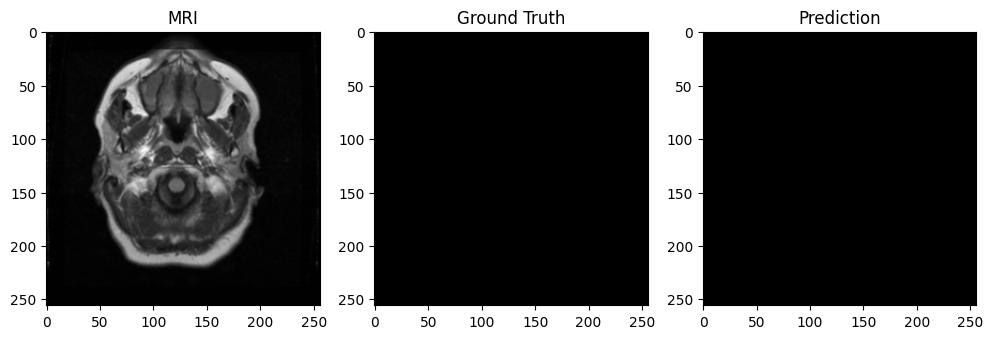

In [ ]:
model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():
    preds = model(images)

pred = preds[0][0].cpu().numpy()
img = images[0][0].cpu().numpy()
mask = masks[0][0].numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Prediction")

plt.savefig("segmentation_result.png")
plt.show()

In [ ]:
tumor_indices = []

for i in range(len(val_masks)):

    mask = cv2.imread(val_masks[i],0)

    if mask.max() > 0:
        tumor_indices.append(i)

print("Tumor slices:", len(tumor_indices))

Tumor slices: 281


In [ ]:
model.eval()

dice_total = 0
sens_total = 0
spec_total = 0
count = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        for i in range(images.shape[0]):

            # skip slices with no tumor
            if masks[i].sum() == 0:
                continue

            pred = outputs[i]
            target = masks[i]

            dice_total += dice_score(pred, target)
            sens_total += sensitivity(pred, target)
            spec_total += specificity(pred, target)

            count += 1

print("Tumor slices evaluated:", count)
print("Dice Score:", (dice_total/count).item())
print("Sensitivity:", (sens_total/count).item())
print("Specificity:", (spec_total/count).item())

Tumor slices evaluated: 281
Dice Score: 0.7058309316635132
Sensitivity: 0.7640513777732849
Specificity: 0.9932337999343872


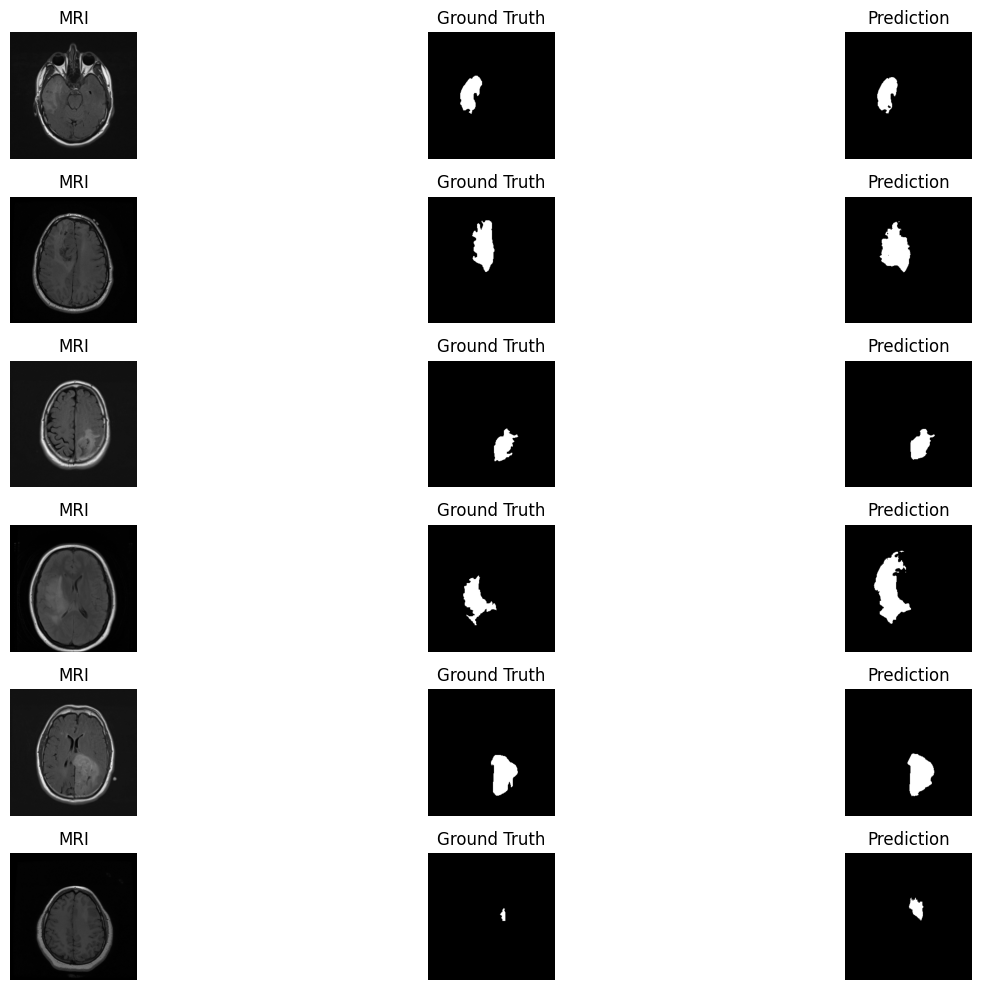

In [ ]:
plt.figure(figsize=(15,10))

shown = 0

for idx in tumor_indices[:6]:

    img = cv2.imread(val_imgs[idx],0)
    mask = cv2.imread(val_masks[idx],0)

    img = cv2.resize(img,(256,256))
    mask = cv2.resize(mask,(256,256))

    img = (img-img.min())/(img.max()-img.min())

    tensor_img = torch.tensor(img).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        pred = model(tensor_img)

    pred = pred.cpu().numpy()[0][0] > 0.4

    plt.subplot(6,3,shown*3+1)
    plt.imshow(img,cmap="gray")
    plt.title("MRI")
    plt.axis("off")

    plt.subplot(6,3,shown*3+2)
    plt.imshow(mask,cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(6,3,shown*3+3)
    plt.imshow(pred,cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    shown += 1

plt.tight_layout()
plt.savefig("segmentation_results.png",dpi=300)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install nibabel
!pip install scikit-image
!pip install pydensecrf
!pip install segmentation-models-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.1 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.5 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_956499e886a7fd943bf670f27674a87e"

In [ ]:
!pip install kaggle

In [ ]:
!kaggle competitions list

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
!kaggle datasets download mateuszbuda/lgg-mri-segmentation

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [ ]:
!kaggle datasets list -s brain tumor

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
import kagglehub

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Path to dataset files: /kaggle/input/lgg-mri-segmentation


In [ ]:
import os

dataset_path = "/kaggle/input/lgg-mri-segmentation"

os.listdir(dataset_path)

['kaggle_3m', 'lgg-mri-segmentation']

In [ ]:
import os

data_path = "/kaggle/input/lgg-mri-segmentation/kaggle_3m"

print(len(os.listdir(data_path)))
os.listdir(data_path)[:5]

112


['TCGA_DU_7010_19860307',
 'TCGA_DU_8162_19961029',
 'TCGA_FG_A4MT_20020212',
 'TCGA_FG_5964_20010511',
 'TCGA_DU_A5TS_19970726']

In [ ]:
import os

data_path = "/kaggle/input/lgg-mri-segmentation/kaggle_3m"

image_paths = []
mask_paths = []

for patient in os.listdir(data_path):

    patient_folder = os.path.join(data_path, patient)

    # skip files like README.md or data.csv
    if not os.path.isdir(patient_folder):
        continue

    for file in os.listdir(patient_folder):

        if file.endswith(".tif") and "mask" not in file:

            img = os.path.join(patient_folder, file)
            mask = os.path.join(patient_folder, file.replace(".tif","_mask.tif"))

            image_paths.append(img)
            mask_paths.append(mask)

print("Total MRI slices:", len(image_paths))

Total MRI slices: 3929


Text(0.5, 1.0, 'Tumor Mask')

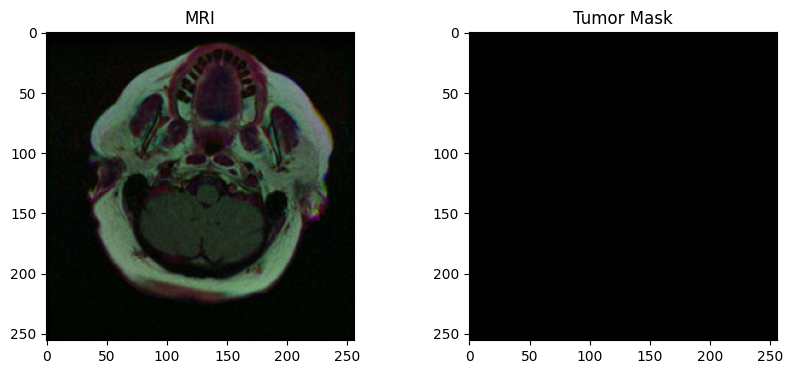

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_paths[10])
mask = cv2.imread(mask_paths[10],0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("MRI")

plt.subplot(1,2,2)
plt.imshow(mask,cmap="gray")
plt.title("Tumor Mask")

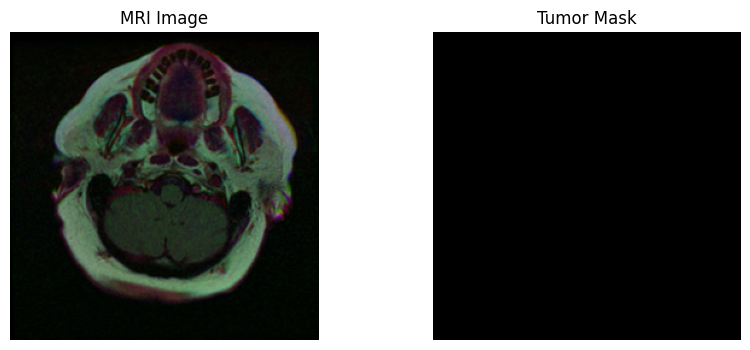

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_paths[10])
mask = cv2.imread(mask_paths[10],0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.show()

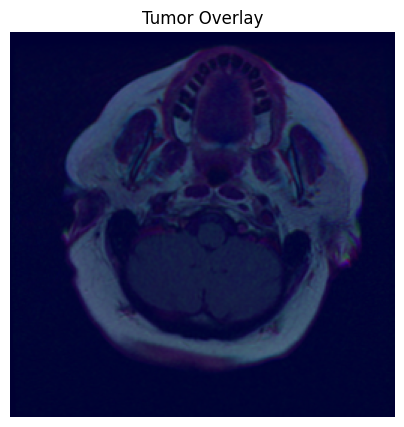

In [ ]:
plt.figure(figsize=(5,5))

plt.imshow(img)
plt.imshow(mask, cmap="jet", alpha=0.4)

plt.title("Tumor Overlay")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

print("Unique mask values:", np.unique(mask))
print("Tumor pixels:", np.sum(mask > 0))

Unique mask values: [0]
Tumor pixels: 0


In [ ]:
for i in range(len(mask_paths)):

    mask = cv2.imread(mask_paths[i],0)

    if mask.max() > 0:
        print("Tumor found at index:", i)
        break

Tumor found at index: 0


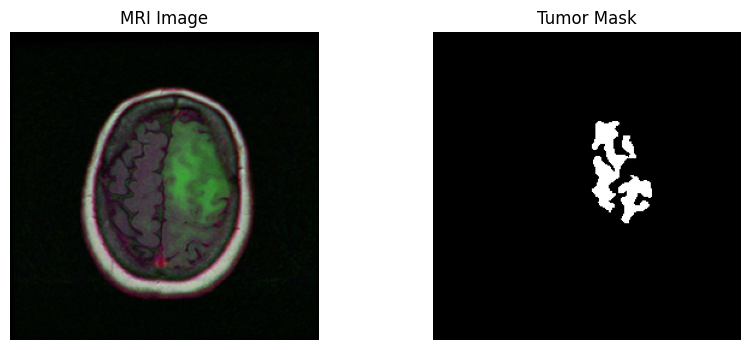

In [ ]:
idx = 0

img = cv2.imread(image_paths[idx])
mask = cv2.imread(mask_paths[idx], 0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=42
)

print("Train images:", len(train_imgs))
print("Validation images:", len(val_imgs))

Train images: 3143
Validation images: 786


In [ ]:
IMG_SIZE = 256

def preprocess(img_path, mask_path):

    img = cv2.imread(img_path,0)
    mask = cv2.imread(mask_path,0)

    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))

    img = img.astype("float32")
    img = (img - img.min()) / (img.max() - img.min())

    mask = mask / 255.0

    return img, mask

In [ ]:
import torch
from torch.utils.data import Dataset

class BrainDataset(Dataset):

    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img, mask = preprocess(self.images[idx], self.masks[idx])

        img = img[np.newaxis,:,:]

        return torch.tensor(img,dtype=torch.float32), torch.tensor(mask,dtype=torch.float32)

In [ ]:
from torch.utils.data import DataLoader

train_dataset = BrainDataset(train_imgs, train_masks)
val_dataset = BrainDataset(val_imgs, val_masks)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):

        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

In [ ]:
class PyramidPooling(nn.Module):

    def __init__(self, in_channels):

        super().__init__()

        self.pool1 = nn.AdaptiveAvgPool2d(1)
        self.pool2 = nn.AdaptiveAvgPool2d(2)
        self.pool3 = nn.AdaptiveAvgPool2d(3)
        self.pool4 = nn.AdaptiveAvgPool2d(6)

    def forward(self, x):

        size = x.size()[2:]

        p1 = F.interpolate(self.pool1(x), size=size, mode='bilinear', align_corners=False)
        p2 = F.interpolate(self.pool2(x), size=size, mode='bilinear', align_corners=False)
        p3 = F.interpolate(self.pool3(x), size=size, mode='bilinear', align_corners=False)
        p4 = F.interpolate(self.pool4(x), size=size, mode='bilinear', align_corners=False)

        return torch.cat([x, p1, p2, p3, p4], dim=1)

In [ ]:
class AttentionUNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder
        self.e1 = ConvBlock(1,64)
        self.e2 = ConvBlock(64,128)
        self.e3 = ConvBlock(128,256)
        self.e4 = ConvBlock(256,512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(512,1024)

        # Pyramid Pooling
        self.ppm = PyramidPooling(1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024*5,512,2,stride=2)
        self.att4 = AttentionBlock(512,512,256)
        self.d4 = ConvBlock(1024,512)

        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.att3 = AttentionBlock(256,256,128)
        self.d3 = ConvBlock(512,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.att2 = AttentionBlock(128,128,64)
        self.d2 = ConvBlock(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.att1 = AttentionBlock(64,64,32)
        self.d1 = ConvBlock(128,64)

        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):

        # Encoder
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Multi-scale
        b = self.ppm(b)

        # Decoder
        d4 = self.up4(b)
        e4 = self.att4(d4,e4)
        d4 = self.d4(torch.cat([d4,e4],dim=1))

        d3 = self.up3(d4)
        e3 = self.att3(d3,e3)
        d3 = self.d3(torch.cat([d3,e3],dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2,e2)
        d2 = self.d2(torch.cat([d2,e2],dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1,e1)
        d1 = self.d1(torch.cat([d1,e1],dim=1))

        return torch.sigmoid(self.out(d1))

In [ ]:
model = AttentionUNet().cuda()

In [ ]:
def dice_loss(pred,target):

    smooth = 1

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()

    return 1 - ((2.*intersection + smooth) /
               (pred.sum() + target.sum() + smooth))

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
for epoch in range(20):

    model.train()

    total_loss = 0

    for images, masks in train_loader:

        images = images.cuda()
        masks = masks.cuda()

        optimizer.zero_grad()

        outputs = model(images)

        loss = dice_loss(outputs, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:",epoch,"Loss:",total_loss/len(train_loader))

Epoch: 0 Loss: 0.9304781123882032
Epoch: 1 Loss: 0.8773979144241973
Epoch: 2 Loss: 0.7740218097927006
Epoch: 3 Loss: 0.6076701477587071
Epoch: 4 Loss: 0.49402589682707654
Epoch: 5 Loss: 0.42619858928612475
Epoch: 6 Loss: 0.41205706563008043
Epoch: 7 Loss: 0.3717344494266364
Epoch: 8 Loss: 0.362877838180872
Epoch: 9 Loss: 0.33152152533446255
Epoch: 10 Loss: 0.30977737054266696
Epoch: 11 Loss: 0.31282981919271646
Epoch: 12 Loss: 0.3284240463611127
Epoch: 13 Loss: 0.26958396371084314
Epoch: 14 Loss: 0.28878045855587675
Epoch: 15 Loss: 0.28052034329518716
Epoch: 16 Loss: 0.2678272981983408
Epoch: 17 Loss: 0.2594860193080271
Epoch: 18 Loss: 0.2510189254775302
Epoch: 19 Loss: 0.23462338438470856


In [ ]:
data_path = "/kaggle/input/lgg-mri-segmentation/kaggle_3m"

image_paths = []
mask_paths = []

for patient in os.listdir(data_path):

    patient_folder = os.path.join(data_path, patient)

    if not os.path.isdir(patient_folder):
        continue

    for file in os.listdir(patient_folder):

        if file.endswith(".tif") and "mask" not in file:

            img = os.path.join(patient_folder,file)
            mask = os.path.join(patient_folder,file.replace(".tif","_mask.tif"))

            image_paths.append(img)
            mask_paths.append(mask)

print("Total MRI slices:", len(image_paths))

Total MRI slices: 3929


In [ ]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=42
)

print(len(train_imgs), len(val_imgs))

3143 786


In [ ]:
class BrainDataset(Dataset):

    def __init__(self, images, masks):

        self.images = images
        self.masks = masks

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img, mask = preprocess(self.images[idx], self.masks[idx])

        img = np.expand_dims(img,0)
        mask = np.expand_dims(mask,0)

        img = torch.tensor(img,dtype=torch.float32)
        mask = torch.tensor(mask,dtype=torch.float32)

        return img, mask

In [ ]:
train_dataset = BrainDataset(train_imgs,train_masks)
val_dataset = BrainDataset(val_imgs,val_masks)

train_loader = DataLoader(train_dataset,batch_size=8,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=8)

In [ ]:
class ConvBlock(nn.Module):

    def __init__(self,in_ch,out_ch):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_ch,out_ch,3,padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch,out_ch,3,padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):

        return self.conv(x)

In [ ]:
class AttentionBlock(nn.Module):

    def __init__(self,F_g,F_l,F_int):

        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g,F_int,1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l,F_int,1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int,1,1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self,g,x):

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1+x1)
        psi = self.psi(psi)

        return x*psi

In [ ]:
class PyramidPooling(nn.Module):

    def __init__(self,in_channels):

        super().__init__()

        self.pool1 = nn.AdaptiveAvgPool2d(1)
        self.pool2 = nn.AdaptiveAvgPool2d(2)
        self.pool3 = nn.AdaptiveAvgPool2d(3)
        self.pool4 = nn.AdaptiveAvgPool2d(6)

    def forward(self,x):

        size = x.size()[2:]

        p1 = F.interpolate(self.pool1(x),size=size,mode="bilinear",align_corners=False)
        p2 = F.interpolate(self.pool2(x),size=size,mode="bilinear",align_corners=False)
        p3 = F.interpolate(self.pool3(x),size=size,mode="bilinear",align_corners=False)
        p4 = F.interpolate(self.pool4(x),size=size,mode="bilinear",align_corners=False)

        return torch.cat([x,p1,p2,p3,p4],dim=1)

In [ ]:
class AttentionUNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.e1 = ConvBlock(1,64)
        self.e2 = ConvBlock(64,128)
        self.e3 = ConvBlock(128,256)
        self.e4 = ConvBlock(256,512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(512,1024)

        self.ppm = PyramidPooling(1024)

        self.up4 = nn.ConvTranspose2d(1024*5,512,2,stride=2)
        self.att4 = AttentionBlock(512,512,256)
        self.d4 = ConvBlock(1024,512)

        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.att3 = AttentionBlock(256,256,128)
        self.d3 = ConvBlock(512,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.att2 = AttentionBlock(128,128,64)
        self.d2 = ConvBlock(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.att1 = AttentionBlock(64,64,32)
        self.d1 = ConvBlock(128,64)

        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):

        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        b = self.ppm(b)

        d4 = self.up4(b)
        e4 = self.att4(d4,e4)
        d4 = self.d4(torch.cat([d4,e4],dim=1))

        d3 = self.up3(d4)
        e3 = self.att3(d3,e3)
        d3 = self.d3(torch.cat([d3,e3],dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2,e2)
        d2 = self.d2(torch.cat([d2,e2],dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1,e1)
        d1 = self.d1(torch.cat([d1,e1],dim=1))

        return torch.sigmoid(self.out(d1))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNet().to(device)

In [ ]:
bce = nn.BCELoss()

def dice_loss(pred,target):

    smooth = 1

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred*target).sum()

    return 1 - ((2*intersection+smooth)/(pred.sum()+target.sum()+smooth))

def combined_loss(pred,target):

    return dice_loss(pred,target) + bce(pred,target)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)

In [ ]:
EPOCHS = 30

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for images,masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs,masks)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:",epoch,"Loss:",total_loss/len(train_loader))

Epoch: 0 Loss: 1.249359351381394
Epoch: 1 Loss: 1.055298831019996
Epoch: 2 Loss: 0.9179870935190119
Epoch: 3 Loss: 0.7668103952595903
Epoch: 4 Loss: 0.6114030589963341
Epoch: 5 Loss: 0.5149180405315855
Epoch: 6 Loss: 0.47093180684567104
Epoch: 7 Loss: 0.4139853104304418
Epoch: 8 Loss: 0.3937197207229131
Epoch: 9 Loss: 0.3973222683366322
Epoch: 10 Loss: 0.3634020399311723
Epoch: 11 Loss: 0.3396883712792366
Epoch: 12 Loss: 0.34928917843118573
Epoch: 13 Loss: 0.3279337069308788
Epoch: 14 Loss: 0.2991761279318472
Epoch: 15 Loss: 0.2890654220399814
Epoch: 16 Loss: 0.3067437698803937
Epoch: 17 Loss: 0.27937019015389847
Epoch: 18 Loss: 0.27341199397054944
Epoch: 19 Loss: 0.28111547459172836
Epoch: 20 Loss: 0.2912186814931816
Epoch: 21 Loss: 0.269333620373226
Epoch: 22 Loss: 0.2518235089081996
Epoch: 23 Loss: 0.2673578942076092
Epoch: 24 Loss: 0.30791769633140725
Epoch: 25 Loss: 0.2596371901095975
Epoch: 26 Loss: 0.28234372147697834
Epoch: 27 Loss: 0.25754910661026115
Epoch: 28 Loss: 0.2520868

In [ ]:
def dice_score(pred, target):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    dice = (2 * intersection) / (union + 1e-8)

    return dice

In [ ]:
def sensitivity(pred, target):

    pred = (pred > 0.5).float()

    TP = (pred * target).sum()
    FN = ((1 - pred) * target).sum()

    return TP / (TP + FN + 1e-8)

In [ ]:
def dice_score(pred, target):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    return (2 * intersection) / (union + 1e-8)


def sensitivity(pred, target):

    pred = (pred > 0.5).float()

    TP = (pred * target).sum()
    FN = ((1 - pred) * target).sum()

    return TP / (TP + FN + 1e-8)


def specificity(pred, target):

    pred = (pred > 0.5).float()

    TN = ((1 - pred) * (1 - target)).sum()
    FP = (pred * (1 - target)).sum()

    return TN / (TN + FP + 1e-8)

In [ ]:
model.eval()

dice_total = 0
sens_total = 0
spec_total = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        dice_total += dice_score(outputs, masks)
        sens_total += sensitivity(outputs, masks)
        spec_total += specificity(outputs, masks)

n = len(val_loader)

print("Dice Score:", (dice_total/n).item())
print("Sensitivity:", (sens_total/n).item())
print("Specificity:", (spec_total/n).item())

Dice Score: 0.7391396760940552
Sensitivity: 0.7814736366271973
Specificity: 0.9972929358482361


In [ ]:
with open("results.txt","w") as f:

    f.write(f"Dice Score: {(dice_total/n).item()}\n")
    f.write(f"Sensitivity: {(sens_total/n).item()}\n")
    f.write(f"Specificity: {(spec_total/n).item()}\n")

In [ ]:
torch.save(model.state_dict(), "attention_unet_brain_tumor.pth")

In [ ]:
torch.save(model, "brain_tumor_model_full.pth")

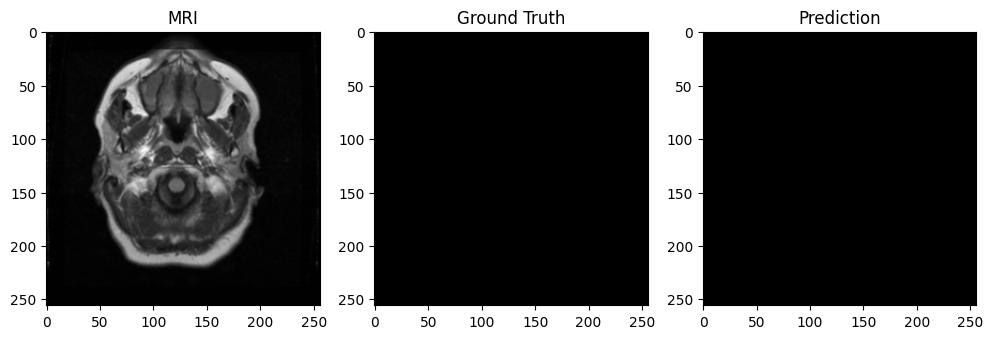

In [ ]:
model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():
    preds = model(images)

pred = preds[0][0].cpu().numpy()
img = images[0][0].cpu().numpy()
mask = masks[0][0].numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Prediction")

plt.savefig("segmentation_result.png")
plt.show()

In [ ]:
tumor_indices = []

for i in range(len(val_masks)):

    mask = cv2.imread(val_masks[i],0)

    if mask.max() > 0:
        tumor_indices.append(i)

print("Tumor slices:", len(tumor_indices))

Tumor slices: 281


In [ ]:
model.eval()

dice_total = 0
sens_total = 0
spec_total = 0
count = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        for i in range(images.shape[0]):

            # skip slices with no tumor
            if masks[i].sum() == 0:
                continue

            pred = outputs[i]
            target = masks[i]

            dice_total += dice_score(pred, target)
            sens_total += sensitivity(pred, target)
            spec_total += specificity(pred, target)

            count += 1

print("Tumor slices evaluated:", count)
print("Dice Score:", (dice_total/count).item())
print("Sensitivity:", (sens_total/count).item())
print("Specificity:", (spec_total/count).item())

Tumor slices evaluated: 281
Dice Score: 0.7058309316635132
Sensitivity: 0.7640513777732849
Specificity: 0.9932337999343872


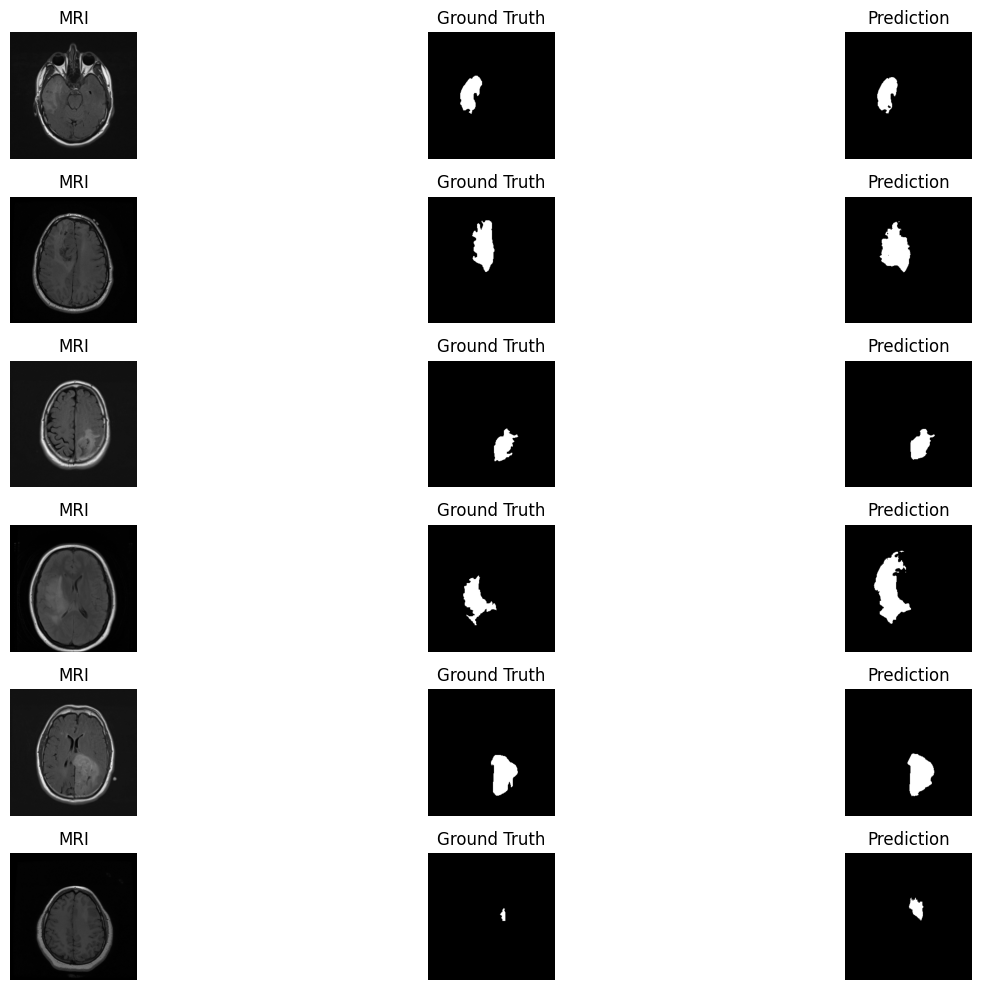

In [ ]:
plt.figure(figsize=(15,10))

shown = 0

for idx in tumor_indices[:6]:

    img = cv2.imread(val_imgs[idx],0)
    mask = cv2.imread(val_masks[idx],0)

    img = cv2.resize(img,(256,256))
    mask = cv2.resize(mask,(256,256))

    img = (img-img.min())/(img.max()-img.min())

    tensor_img = torch.tensor(img).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        pred = model(tensor_img)

    pred = pred.cpu().numpy()[0][0] > 0.4

    plt.subplot(6,3,shown*3+1)
    plt.imshow(img,cmap="gray")
    plt.title("MRI")
    plt.axis("off")

    plt.subplot(6,3,shown*3+2)
    plt.imshow(mask,cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(6,3,shown*3+3)
    plt.imshow(pred,cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    shown += 1

plt.tight_layout()
plt.savefig("segmentation_results.png",dpi=300)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install nibabel
!pip install scikit-image
!pip install pydensecrf
!pip install segmentation-models-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.1 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.5 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_956499e886a7fd943bf670f27674a87e"

In [ ]:
!pip install kaggle

In [ ]:
!kaggle competitions list

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
!kaggle datasets download mateuszbuda/lgg-mri-segmentation

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [ ]:
!kaggle datasets list -s brain tumor

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
import kagglehub

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Path to dataset files: /kaggle/input/lgg-mri-segmentation


In [ ]:
import os

dataset_path = "/kaggle/input/lgg-mri-segmentation"

os.listdir(dataset_path)

['kaggle_3m', 'lgg-mri-segmentation']

In [ ]:
import os

data_path = "/kaggle/input/lgg-mri-segmentation/kaggle_3m"

print(len(os.listdir(data_path)))
os.listdir(data_path)[:5]

112


['TCGA_DU_7010_19860307',
 'TCGA_DU_8162_19961029',
 'TCGA_FG_A4MT_20020212',
 'TCGA_FG_5964_20010511',
 'TCGA_DU_A5TS_19970726']

In [ ]:
import os

data_path = "/kaggle/input/lgg-mri-segmentation/kaggle_3m"

image_paths = []
mask_paths = []

for patient in os.listdir(data_path):

    patient_folder = os.path.join(data_path, patient)

    # skip files like README.md or data.csv
    if not os.path.isdir(patient_folder):
        continue

    for file in os.listdir(patient_folder):

        if file.endswith(".tif") and "mask" not in file:

            img = os.path.join(patient_folder, file)
            mask = os.path.join(patient_folder, file.replace(".tif","_mask.tif"))

            image_paths.append(img)
            mask_paths.append(mask)

print("Total MRI slices:", len(image_paths))

Total MRI slices: 3929


Text(0.5, 1.0, 'Tumor Mask')

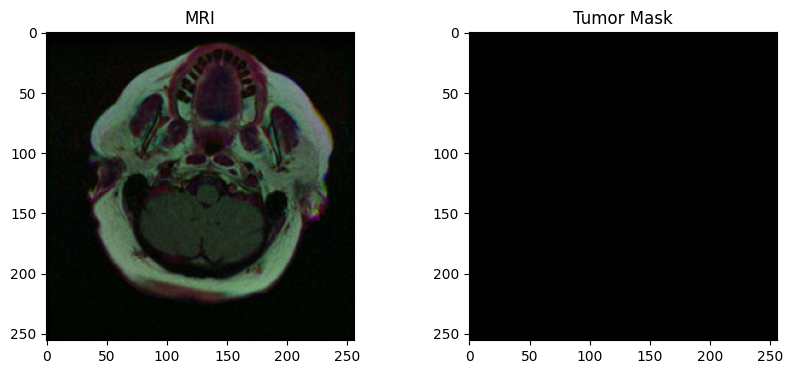

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_paths[10])
mask = cv2.imread(mask_paths[10],0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("MRI")

plt.subplot(1,2,2)
plt.imshow(mask,cmap="gray")
plt.title("Tumor Mask")

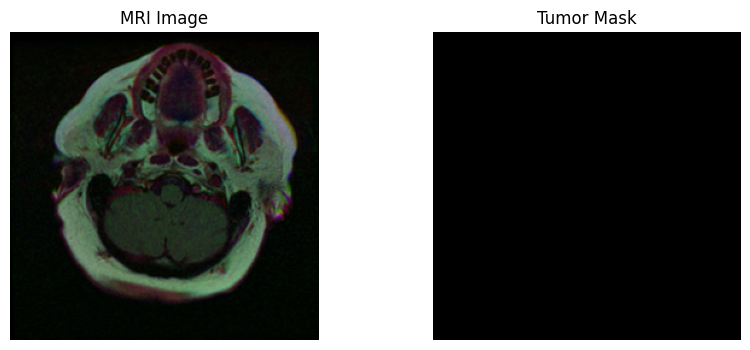

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_paths[10])
mask = cv2.imread(mask_paths[10],0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.show()

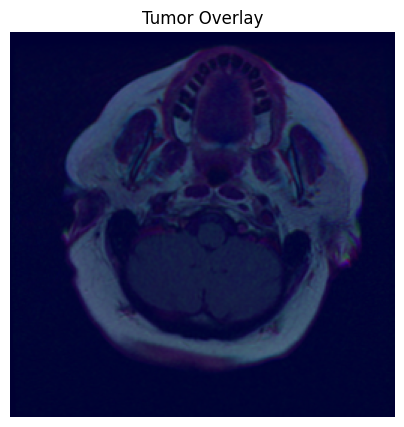

In [ ]:
plt.figure(figsize=(5,5))

plt.imshow(img)
plt.imshow(mask, cmap="jet", alpha=0.4)

plt.title("Tumor Overlay")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

print("Unique mask values:", np.unique(mask))
print("Tumor pixels:", np.sum(mask > 0))

Unique mask values: [0]
Tumor pixels: 0


In [ ]:
for i in range(len(mask_paths)):

    mask = cv2.imread(mask_paths[i],0)

    if mask.max() > 0:
        print("Tumor found at index:", i)
        break

Tumor found at index: 0


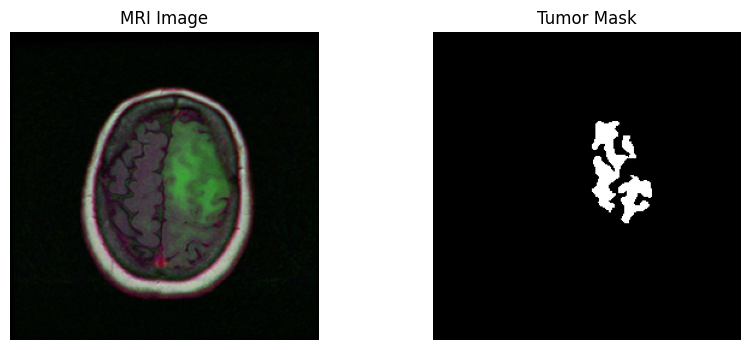

In [ ]:
idx = 0

img = cv2.imread(image_paths[idx])
mask = cv2.imread(mask_paths[idx], 0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=42
)

print("Train images:", len(train_imgs))
print("Validation images:", len(val_imgs))

Train images: 3143
Validation images: 786


In [ ]:
IMG_SIZE = 256

def preprocess(img_path, mask_path):

    img = cv2.imread(img_path,0)
    mask = cv2.imread(mask_path,0)

    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))

    img = img.astype("float32")
    img = (img - img.min()) / (img.max() - img.min())

    mask = mask / 255.0

    return img, mask

In [ ]:
import torch
from torch.utils.data import Dataset

class BrainDataset(Dataset):

    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img, mask = preprocess(self.images[idx], self.masks[idx])

        img = img[np.newaxis,:,:]

        return torch.tensor(img,dtype=torch.float32), torch.tensor(mask,dtype=torch.float32)

In [ ]:
from torch.utils.data import DataLoader

train_dataset = BrainDataset(train_imgs, train_masks)
val_dataset = BrainDataset(val_imgs, val_masks)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):

        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

In [ ]:
class PyramidPooling(nn.Module):

    def __init__(self, in_channels):

        super().__init__()

        self.pool1 = nn.AdaptiveAvgPool2d(1)
        self.pool2 = nn.AdaptiveAvgPool2d(2)
        self.pool3 = nn.AdaptiveAvgPool2d(3)
        self.pool4 = nn.AdaptiveAvgPool2d(6)

    def forward(self, x):

        size = x.size()[2:]

        p1 = F.interpolate(self.pool1(x), size=size, mode='bilinear', align_corners=False)
        p2 = F.interpolate(self.pool2(x), size=size, mode='bilinear', align_corners=False)
        p3 = F.interpolate(self.pool3(x), size=size, mode='bilinear', align_corners=False)
        p4 = F.interpolate(self.pool4(x), size=size, mode='bilinear', align_corners=False)

        return torch.cat([x, p1, p2, p3, p4], dim=1)

In [ ]:
class AttentionUNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder
        self.e1 = ConvBlock(1,64)
        self.e2 = ConvBlock(64,128)
        self.e3 = ConvBlock(128,256)
        self.e4 = ConvBlock(256,512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(512,1024)

        # Pyramid Pooling
        self.ppm = PyramidPooling(1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024*5,512,2,stride=2)
        self.att4 = AttentionBlock(512,512,256)
        self.d4 = ConvBlock(1024,512)

        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.att3 = AttentionBlock(256,256,128)
        self.d3 = ConvBlock(512,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.att2 = AttentionBlock(128,128,64)
        self.d2 = ConvBlock(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.att1 = AttentionBlock(64,64,32)
        self.d1 = ConvBlock(128,64)

        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):

        # Encoder
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Multi-scale
        b = self.ppm(b)

        # Decoder
        d4 = self.up4(b)
        e4 = self.att4(d4,e4)
        d4 = self.d4(torch.cat([d4,e4],dim=1))

        d3 = self.up3(d4)
        e3 = self.att3(d3,e3)
        d3 = self.d3(torch.cat([d3,e3],dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2,e2)
        d2 = self.d2(torch.cat([d2,e2],dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1,e1)
        d1 = self.d1(torch.cat([d1,e1],dim=1))

        return torch.sigmoid(self.out(d1))

In [ ]:
model = AttentionUNet().cuda()

In [ ]:
def dice_loss(pred,target):

    smooth = 1

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()

    return 1 - ((2.*intersection + smooth) /
               (pred.sum() + target.sum() + smooth))

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
for epoch in range(20):

    model.train()

    total_loss = 0

    for images, masks in train_loader:

        images = images.cuda()
        masks = masks.cuda()

        optimizer.zero_grad()

        outputs = model(images)

        loss = dice_loss(outputs, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:",epoch,"Loss:",total_loss/len(train_loader))

Epoch: 0 Loss: 0.9304781123882032
Epoch: 1 Loss: 0.8773979144241973
Epoch: 2 Loss: 0.7740218097927006
Epoch: 3 Loss: 0.6076701477587071
Epoch: 4 Loss: 0.49402589682707654
Epoch: 5 Loss: 0.42619858928612475
Epoch: 6 Loss: 0.41205706563008043
Epoch: 7 Loss: 0.3717344494266364
Epoch: 8 Loss: 0.362877838180872
Epoch: 9 Loss: 0.33152152533446255
Epoch: 10 Loss: 0.30977737054266696
Epoch: 11 Loss: 0.31282981919271646
Epoch: 12 Loss: 0.3284240463611127
Epoch: 13 Loss: 0.26958396371084314
Epoch: 14 Loss: 0.28878045855587675
Epoch: 15 Loss: 0.28052034329518716
Epoch: 16 Loss: 0.2678272981983408
Epoch: 17 Loss: 0.2594860193080271
Epoch: 18 Loss: 0.2510189254775302
Epoch: 19 Loss: 0.23462338438470856


In [ ]:
data_path = "/kaggle/input/lgg-mri-segmentation/kaggle_3m"

image_paths = []
mask_paths = []

for patient in os.listdir(data_path):

    patient_folder = os.path.join(data_path, patient)

    if not os.path.isdir(patient_folder):
        continue

    for file in os.listdir(patient_folder):

        if file.endswith(".tif") and "mask" not in file:

            img = os.path.join(patient_folder,file)
            mask = os.path.join(patient_folder,file.replace(".tif","_mask.tif"))

            image_paths.append(img)
            mask_paths.append(mask)

print("Total MRI slices:", len(image_paths))

Total MRI slices: 3929


In [ ]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=42
)

print(len(train_imgs), len(val_imgs))

3143 786


In [ ]:
class BrainDataset(Dataset):

    def __init__(self, images, masks):

        self.images = images
        self.masks = masks

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img, mask = preprocess(self.images[idx], self.masks[idx])

        img = np.expand_dims(img,0)
        mask = np.expand_dims(mask,0)

        img = torch.tensor(img,dtype=torch.float32)
        mask = torch.tensor(mask,dtype=torch.float32)

        return img, mask

In [ ]:
train_dataset = BrainDataset(train_imgs,train_masks)
val_dataset = BrainDataset(val_imgs,val_masks)

train_loader = DataLoader(train_dataset,batch_size=8,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=8)

In [ ]:
class ConvBlock(nn.Module):

    def __init__(self,in_ch,out_ch):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_ch,out_ch,3,padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch,out_ch,3,padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):

        return self.conv(x)

In [ ]:
class AttentionBlock(nn.Module):

    def __init__(self,F_g,F_l,F_int):

        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g,F_int,1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l,F_int,1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int,1,1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self,g,x):

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1+x1)
        psi = self.psi(psi)

        return x*psi

In [ ]:
class PyramidPooling(nn.Module):

    def __init__(self,in_channels):

        super().__init__()

        self.pool1 = nn.AdaptiveAvgPool2d(1)
        self.pool2 = nn.AdaptiveAvgPool2d(2)
        self.pool3 = nn.AdaptiveAvgPool2d(3)
        self.pool4 = nn.AdaptiveAvgPool2d(6)

    def forward(self,x):

        size = x.size()[2:]

        p1 = F.interpolate(self.pool1(x),size=size,mode="bilinear",align_corners=False)
        p2 = F.interpolate(self.pool2(x),size=size,mode="bilinear",align_corners=False)
        p3 = F.interpolate(self.pool3(x),size=size,mode="bilinear",align_corners=False)
        p4 = F.interpolate(self.pool4(x),size=size,mode="bilinear",align_corners=False)

        return torch.cat([x,p1,p2,p3,p4],dim=1)

In [ ]:
class AttentionUNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.e1 = ConvBlock(1,64)
        self.e2 = ConvBlock(64,128)
        self.e3 = ConvBlock(128,256)
        self.e4 = ConvBlock(256,512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(512,1024)

        self.ppm = PyramidPooling(1024)

        self.up4 = nn.ConvTranspose2d(1024*5,512,2,stride=2)
        self.att4 = AttentionBlock(512,512,256)
        self.d4 = ConvBlock(1024,512)

        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.att3 = AttentionBlock(256,256,128)
        self.d3 = ConvBlock(512,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.att2 = AttentionBlock(128,128,64)
        self.d2 = ConvBlock(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.att1 = AttentionBlock(64,64,32)
        self.d1 = ConvBlock(128,64)

        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):

        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        b = self.ppm(b)

        d4 = self.up4(b)
        e4 = self.att4(d4,e4)
        d4 = self.d4(torch.cat([d4,e4],dim=1))

        d3 = self.up3(d4)
        e3 = self.att3(d3,e3)
        d3 = self.d3(torch.cat([d3,e3],dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2,e2)
        d2 = self.d2(torch.cat([d2,e2],dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1,e1)
        d1 = self.d1(torch.cat([d1,e1],dim=1))

        return torch.sigmoid(self.out(d1))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNet().to(device)

In [ ]:
bce = nn.BCELoss()

def dice_loss(pred,target):

    smooth = 1

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred*target).sum()

    return 1 - ((2*intersection+smooth)/(pred.sum()+target.sum()+smooth))

def combined_loss(pred,target):

    return dice_loss(pred,target) + bce(pred,target)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)

In [ ]:
EPOCHS = 30

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for images,masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs,masks)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:",epoch,"Loss:",total_loss/len(train_loader))

Epoch: 0 Loss: 1.249359351381394
Epoch: 1 Loss: 1.055298831019996
Epoch: 2 Loss: 0.9179870935190119
Epoch: 3 Loss: 0.7668103952595903
Epoch: 4 Loss: 0.6114030589963341
Epoch: 5 Loss: 0.5149180405315855
Epoch: 6 Loss: 0.47093180684567104
Epoch: 7 Loss: 0.4139853104304418
Epoch: 8 Loss: 0.3937197207229131
Epoch: 9 Loss: 0.3973222683366322
Epoch: 10 Loss: 0.3634020399311723
Epoch: 11 Loss: 0.3396883712792366
Epoch: 12 Loss: 0.34928917843118573
Epoch: 13 Loss: 0.3279337069308788
Epoch: 14 Loss: 0.2991761279318472
Epoch: 15 Loss: 0.2890654220399814
Epoch: 16 Loss: 0.3067437698803937
Epoch: 17 Loss: 0.27937019015389847
Epoch: 18 Loss: 0.27341199397054944
Epoch: 19 Loss: 0.28111547459172836
Epoch: 20 Loss: 0.2912186814931816
Epoch: 21 Loss: 0.269333620373226
Epoch: 22 Loss: 0.2518235089081996
Epoch: 23 Loss: 0.2673578942076092
Epoch: 24 Loss: 0.30791769633140725
Epoch: 25 Loss: 0.2596371901095975
Epoch: 26 Loss: 0.28234372147697834
Epoch: 27 Loss: 0.25754910661026115
Epoch: 28 Loss: 0.2520868

In [ ]:
def dice_score(pred, target):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    dice = (2 * intersection) / (union + 1e-8)

    return dice

In [ ]:
def sensitivity(pred, target):

    pred = (pred > 0.5).float()

    TP = (pred * target).sum()
    FN = ((1 - pred) * target).sum()

    return TP / (TP + FN + 1e-8)

In [ ]:
def dice_score(pred, target):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    return (2 * intersection) / (union + 1e-8)


def sensitivity(pred, target):

    pred = (pred > 0.5).float()

    TP = (pred * target).sum()
    FN = ((1 - pred) * target).sum()

    return TP / (TP + FN + 1e-8)


def specificity(pred, target):

    pred = (pred > 0.5).float()

    TN = ((1 - pred) * (1 - target)).sum()
    FP = (pred * (1 - target)).sum()

    return TN / (TN + FP + 1e-8)

In [ ]:
model.eval()

dice_total = 0
sens_total = 0
spec_total = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        dice_total += dice_score(outputs, masks)
        sens_total += sensitivity(outputs, masks)
        spec_total += specificity(outputs, masks)

n = len(val_loader)

print("Dice Score:", (dice_total/n).item())
print("Sensitivity:", (sens_total/n).item())
print("Specificity:", (spec_total/n).item())

Dice Score: 0.7391396760940552
Sensitivity: 0.7814736366271973
Specificity: 0.9972929358482361


In [ ]:
with open("results.txt","w") as f:

    f.write(f"Dice Score: {(dice_total/n).item()}\n")
    f.write(f"Sensitivity: {(sens_total/n).item()}\n")
    f.write(f"Specificity: {(spec_total/n).item()}\n")

In [ ]:
torch.save(model.state_dict(), "attention_unet_brain_tumor.pth")

In [ ]:
torch.save(model, "brain_tumor_model_full.pth")

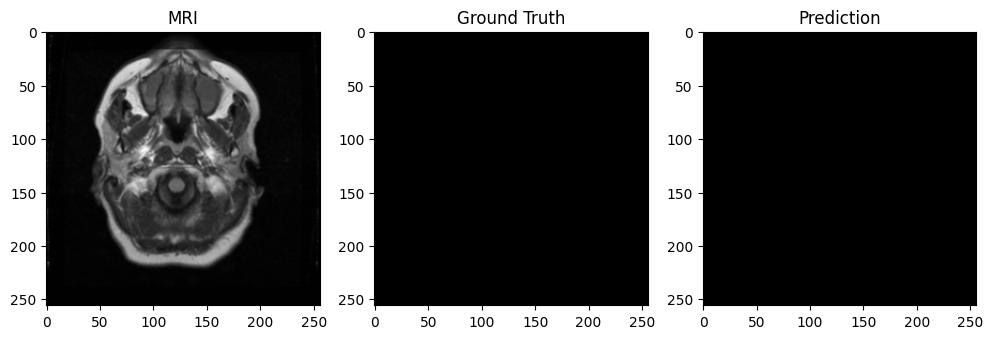

In [ ]:
model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():
    preds = model(images)

pred = preds[0][0].cpu().numpy()
img = images[0][0].cpu().numpy()
mask = masks[0][0].numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Prediction")

plt.savefig("segmentation_result.png")
plt.show()

In [ ]:
tumor_indices = []

for i in range(len(val_masks)):

    mask = cv2.imread(val_masks[i],0)

    if mask.max() > 0:
        tumor_indices.append(i)

print("Tumor slices:", len(tumor_indices))

Tumor slices: 281


In [ ]:
model.eval()

dice_total = 0
sens_total = 0
spec_total = 0
count = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        for i in range(images.shape[0]):

            # skip slices with no tumor
            if masks[i].sum() == 0:
                continue

            pred = outputs[i]
            target = masks[i]

            dice_total += dice_score(pred, target)
            sens_total += sensitivity(pred, target)
            spec_total += specificity(pred, target)

            count += 1

print("Tumor slices evaluated:", count)
print("Dice Score:", (dice_total/count).item())
print("Sensitivity:", (sens_total/count).item())
print("Specificity:", (spec_total/count).item())

Tumor slices evaluated: 281
Dice Score: 0.7058309316635132
Sensitivity: 0.7640513777732849
Specificity: 0.9932337999343872


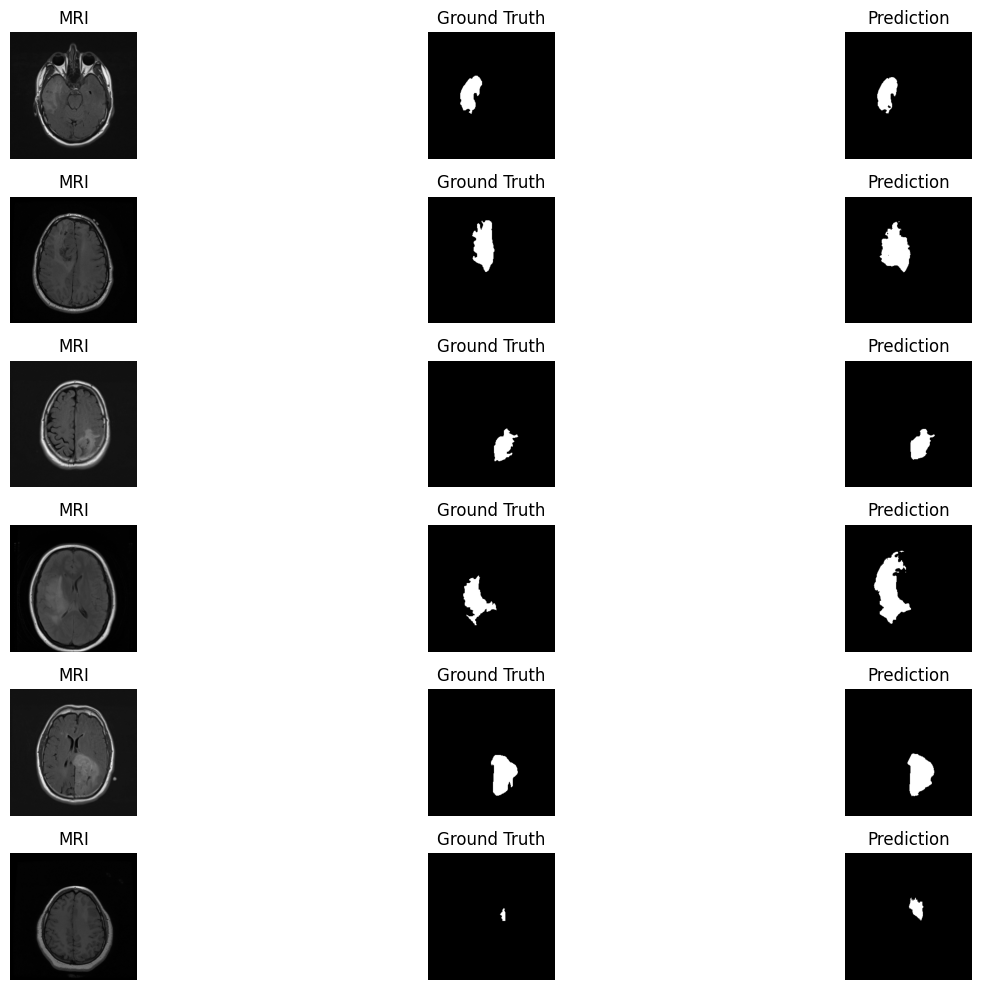

In [ ]:
plt.figure(figsize=(15,10))

shown = 0

for idx in tumor_indices[:6]:

    img = cv2.imread(val_imgs[idx],0)
    mask = cv2.imread(val_masks[idx],0)

    img = cv2.resize(img,(256,256))
    mask = cv2.resize(mask,(256,256))

    img = (img-img.min())/(img.max()-img.min())

    tensor_img = torch.tensor(img).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        pred = model(tensor_img)

    pred = pred.cpu().numpy()[0][0] > 0.4

    plt.subplot(6,3,shown*3+1)
    plt.imshow(img,cmap="gray")
    plt.title("MRI")
    plt.axis("off")

    plt.subplot(6,3,shown*3+2)
    plt.imshow(mask,cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(6,3,shown*3+3)
    plt.imshow(pred,cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    shown += 1

plt.tight_layout()
plt.savefig("segmentation_results.png",dpi=300)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
class BrainDataset(Dataset):
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx], 0)
        img = cv2.resize(img, (256,256))
        img = img / 255.0

        mask = cv2.imread(self.masks[idx], 0)
        mask = cv2.resize(mask, (256,256))
        mask = mask / 255.0

        img = np.expand_dims(img, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c)

        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)

        self.relu = nn.ReLU()
        self.skip = nn.Conv2d(in_c, out_c, 1)

    def forward(self, x):
        identity = self.skip(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += identity
        return self.relu(out)

In [ ]:
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = torch.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

In [ ]:
class PyramidPooling(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.pool1 = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, in_channels//4, 1)
        )

        self.pool2 = nn.Sequential(
            nn.AdaptiveAvgPool2d(2),
            nn.Conv2d(in_channels, in_channels//4, 1)
        )

        self.pool3 = nn.Sequential(
            nn.AdaptiveAvgPool2d(3),
            nn.Conv2d(in_channels, in_channels//4, 1)
        )

        self.pool4 = nn.Sequential(
            nn.AdaptiveAvgPool2d(6),
            nn.Conv2d(in_channels, in_channels//4, 1)
        )

    def forward(self, x):
        size = x.size()[2:]

        p1 = F.interpolate(self.pool1(x), size)
        p2 = F.interpolate(self.pool2(x), size)
        p3 = F.interpolate(self.pool3(x), size)
        p4 = F.interpolate(self.pool4(x), size)

        return torch.cat([x, p1, p2, p3, p4], dim=1)

In [ ]:
class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ResidualBlock(1, 64)
        self.enc2 = ResidualBlock(64, 128)
        self.enc3 = ResidualBlock(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.ppm = PyramidPooling(256)

        self.up2 = nn.ConvTranspose2d(256*2, 128, 2, stride=2)
        self.att2 = AttentionBlock(128,128,64)
        self.dec2 = ResidualBlock(256,128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att1 = AttentionBlock(64,64,32)
        self.dec1 = ResidualBlock(128,64)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        p = self.ppm(e3)

        d2 = self.up2(p)
        e2_att = self.att2(d2,e2)
        d2 = self.dec2(torch.cat([d2,e2_att],dim=1))

        d1 = self.up1(d2)
        e1_att = self.att1(d1,e1)
        d1 = self.dec1(torch.cat([d1,e1_att],dim=1))

        return torch.sigmoid(self.final(d1))

In [ ]:
def dice_loss(pred, target):
    smooth = 1
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()

    return 1 - ((2 * intersection + smooth) /
                (pred.sum() + target.sum() + smooth))


def focal_loss(pred, target, alpha=0.8, gamma=2):
    bce = F.binary_cross_entropy(pred, target, reduction='none')
    pt = torch.exp(-bce)
    focal = alpha * (1 - pt) ** gamma * bce
    return focal.mean()


def combined_loss(pred, target):
    return 0.5*dice_loss(pred,target) + \
           0.3*F.binary_cross_entropy(pred,target) + \
           0.2*focal_loss(pred,target)

In [ ]:
import kagglehub

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

100%|██████████| 714M/714M [00:08<00:00, 85.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2


In [ ]:
import os

base_path = "/root/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2"

print(os.listdir(base_path))

['kaggle_3m', 'lgg-mri-segmentation']


In [ ]:
data_path = "/root/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2/kaggle_3m"

In [ ]:
import os

image_paths = []
mask_paths = []

for folder in os.listdir(data_path):

    folder_path = os.path.join(data_path, folder)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):

        if file.endswith(".tif") and "mask" not in file:

            img_path = os.path.join(folder_path, file)
            mask_path = os.path.join(folder_path, file.replace(".tif", "_mask.tif"))

            if os.path.exists(mask_path):
                image_paths.append(img_path)
                mask_paths.append(mask_path)

print("Total images:", len(image_paths))

Total images: 3929


In [ ]:
import cv2

filtered_imgs = []
filtered_masks = []

for img, mask in zip(image_paths, mask_paths):

    m = cv2.imread(mask, 0)

    if m.max() > 0:
        filtered_imgs.append(img)
        filtered_masks.append(mask)

image_paths = filtered_imgs
mask_paths = filtered_masks

print("Tumor images:", len(image_paths))

Tumor images: 1373


In [ ]:
from sklearn.model_selection import train_test_split

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

In [ ]:
from torch.utils.data import DataLoader

train_dataset = BrainDataset(train_imgs, train_masks)
val_dataset = BrainDataset(val_imgs, val_masks)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [ ]:
images, masks = next(iter(train_loader))

print(images.shape)  # should be [8, 1, 256, 256]
print(masks.shape)

torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
import torch.nn.functional as F

def dice_loss(pred, target):
    smooth = 1
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def focal_loss(pred, target, alpha=0.8, gamma=2):
    bce = F.binary_cross_entropy(pred, target, reduction='none')
    pt = torch.exp(-bce)
    return (alpha * (1 - pt) ** gamma * bce).mean()


def combined_loss(pred, target):
    return 0.5 * dice_loss(pred, target) + \
           0.3 * F.binary_cross_entropy(pred, target) + \
           0.2 * focal_loss(pred, target)

In [ ]:
def dice_score(pred, target):
    pred = (pred > 0.4).float()

    intersection = (pred * target).sum()
    return (2 * intersection) / (pred.sum() + target.sum() + 1e-8)

In [ ]:
EPOCHS = 30

train_losses = []
val_dices = []

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    model.train()
    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ---- VALIDATION ----
    model.eval()
    dice_total = 0

    with torch.no_grad():
        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            dice_total += dice_score(outputs, masks)

    avg_dice = (dice_total / len(val_loader)).item()
    val_dices.append(avg_dice)

    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Dice={avg_dice:.4f}")

Epoch 1: Loss=0.4560, Dice=0.4944
Epoch 2: Loss=0.2641, Dice=0.5867


In [ ]:
model = UNet().to(device)
model.load_state_dict(torch.load("/content/brain_tumor_model_full.pth"))

NameError: name 'UNet' is not defined

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Conv Block
# -------------------------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# -------------------------
# Attention Gate
# -------------------------
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

# -------------------------
# Pyramid Pooling
# -------------------------
class PyramidPooling(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.pool1 = nn.AdaptiveAvgPool2d(1)
        self.pool2 = nn.AdaptiveAvgPool2d(2)
        self.pool3 = nn.AdaptiveAvgPool2d(3)
        self.pool4 = nn.AdaptiveAvgPool2d(6)

    def forward(self, x):
        size = x.size()[2:]

        p1 = F.interpolate(self.pool1(x), size=size, mode='bilinear', align_corners=False)
        p2 = F.interpolate(self.pool2(x), size=size, mode='bilinear', align_corners=False)
        p3 = F.interpolate(self.pool3(x), size=size, mode='bilinear', align_corners=False)
        p4 = F.interpolate(self.pool4(x), size=size, mode='bilinear', align_corners=False)

        return torch.cat([x, p1, p2, p3, p4], dim=1)

# -------------------------
# Full Model
# -------------------------
class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.e1 = ConvBlock(1,64)
        self.e2 = ConvBlock(64,128)
        self.e3 = ConvBlock(128,256)
        self.e4 = ConvBlock(256,512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(512,1024)
        self.ppm = PyramidPooling(1024)

        self.up4 = nn.ConvTranspose2d(1024*5,512,2,stride=2)
        self.att4 = AttentionBlock(512,512,256)
        self.d4 = ConvBlock(1024,512)

        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.att3 = AttentionBlock(256,256,128)
        self.d3 = ConvBlock(512,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.att2 = AttentionBlock(128,128,64)
        self.d2 = ConvBlock(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.att1 = AttentionBlock(64,64,32)
        self.d1 = ConvBlock(128,64)

        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))
        b = self.ppm(b)

        d4 = self.up4(b)
        e4 = self.att4(d4,e4)
        d4 = self.d4(torch.cat([d4,e4],dim=1))

        d3 = self.up3(d4)
        e3 = self.att3(d3,e3)
        d3 = self.d3(torch.cat([d3,e3],dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2,e2)
        d2 = self.d2(torch.cat([d2,e2],dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1,e1)
        d1 = self.d1(torch.cat([d1,e1],dim=1))

        return torch.sigmoid(self.out(d1))

In [ ]:
# Use this if you want to load the "full" model file
model = torch.load("/content/brain_tumor_model_full.pth", map_location=device, weights_only=False)

model.eval()
print("Full model loaded successfully!")

Full model loaded successfully!


In [ ]:
model.eval()

AttentionUNet(
  (e1): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (e2): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (e3): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=

In [ ]:
import numpy as np
import time

def evaluate_model(model, loader, device):
    model.eval()

    TP = FP = TN = FN = 0
    dice_scores = []
    iou_scores = []
    inference_times = []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            start = time.time()
            preds = model(imgs)
            end = time.time()

            inference_times.append((end-start)/imgs.size(0))

            preds = (preds > 0.5).float()

            TP += ((preds==1) & (masks==1)).sum().item()
            FP += ((preds==1) & (masks==0)).sum().item()
            TN += ((preds==0) & (masks==0)).sum().item()
            FN += ((preds==0) & (masks==1)).sum().item()

            for i in range(imgs.size(0)):
                p = preds[i].view(-1)
                t = masks[i].view(-1)

                inter = (p*t).sum()
                union = p.sum() + t.sum()

                dice = (2*inter+1e-6)/(union+1e-6)
                iou = (inter+1e-6)/(union-inter+1e-6)

                dice_scores.append(dice.item())
                iou_scores.append(iou.item())

    precision = TP/(TP+FP+1e-6)
    recall = TP/(TP+FN+1e-6)
    specificity = TN/(TN+FP+1e-6)
    accuracy = (TP+TN)/(TP+TN+FP+FN+1e-6)
    f1 = 2*precision*recall/(precision+recall+1e-6)

    print("Dice:", np.mean(dice_scores))
    print("IoU:", np.mean(iou_scores))
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Specificity:", specificity)
    print("F1:", f1)
    print("FPR:", FP/(FP+TN+1e-6))
    print("FNR:", FN/(FN+TP+1e-6))
    print("Inference Time:", np.mean(inference_times), "sec/image")

In [ ]:
def evaluate_model(model, loader, device):
    model.eval()

    TP = FP = TN = FN = 0
    dice_scores = []
    iou_scores = []
    inference_times = []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            start = time.time()
            preds = model(imgs)
            end = time.time()

            inference_times.append((end - start) / imgs.size(0))

            preds_bin = (preds > 0.5).float()

            TP += ((preds_bin == 1) & (masks == 1)).sum().item()
            FP += ((preds_bin == 1) & (masks == 0)).sum().item()
            TN += ((preds_bin == 0) & (masks == 0)).sum().item()
            FN += ((preds_bin == 0) & (masks == 1)).sum().item()

            # Dice + IoU batchwise
            for i in range(imgs.size(0)):
                p = preds_bin[i].view(-1)
                t = masks[i].view(-1)

                inter = (p * t).sum()
                union = p.sum() + t.sum()

                dice = (2 * inter + 1e-6) / (union + 1e-6)
                iou = (inter + 1e-6) / (union - inter + 1e-6)

                dice_scores.append(dice.item())
                iou_scores.append(iou.item())

    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    sensitivity = recall
    specificity = TN / (TN + FP + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    fpr = FP / (FP + TN + 1e-6)
    fnr = FN / (FN + TP + 1e-6)
    mean_pixel_acc = accuracy
    avg_inference = np.mean(inference_times)

    metrics = {
        "Dice": np.mean(dice_scores),
        "IoU": np.mean(iou_scores),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1 Score": f1,
        "FPR": fpr,
        "FNR": fnr,
        "Mean Pixel Accuracy": mean_pixel_acc,
        "Inference Time (sec/img)": avg_inference,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN
    }

    return metrics

In [ ]:
import numpy as np
import time

def evaluate_model(model, loader, device):
    model.eval()

    TP = FP = TN = FN = 0
    dice_scores = []
    iou_scores = []
    inference_times = []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            start = time.time()
            preds = model(imgs)
            end = time.time()

            inference_times.append((end-start)/imgs.size(0))

            preds = (preds > 0.5).float()

            TP += ((preds==1) & (masks==1)).sum().item()
            FP += ((preds==1) & (masks==0)).sum().item()
            TN += ((preds==0) & (masks==0)).sum().item()
            FN += ((preds==0) & (masks==1)).sum().item()

            for i in range(imgs.size(0)):
                p = preds[i].view(-1)
                t = masks[i].view(-1)

                inter = (p*t).sum()
                union = p.sum() + t.sum()

                dice = (2*inter+1e-6)/(union+1e-6)
                iou = (inter+1e-6)/(union-inter+1e-6)

                dice_scores.append(dice.item())
                iou_scores.append(iou.item())

    precision = TP/(TP+FP+1e-6)
    recall = TP/(TP+FN+1e-6)
    specificity = TN/(TN+FP+1e-6)
    accuracy = (TP+TN)/(TP+TN+FP+FN+1e-6)
    f1 = 2*precision*recall/(precision+recall+1e-6)

    print("Dice:", np.mean(dice_scores))
    print("IoU:", np.mean(iou_scores))
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Specificity:", specificity)
    print("F1:", f1)
    print("FPR:", FP/(FP+TN+1e-6))
    print("FNR:", FN/(FN+TP+1e-6))
    print("Inference Time:", np.mean(inference_times), "sec/image")

In [ ]:
import os
import cv2
import numpy as np
import kagglehub
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader

In [ ]:
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
print(path)

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
/kaggle/input/lgg-mri-segmentation


In [ ]:
data_dir = os.path.join(path, "kaggle_3m")

image_paths = []
mask_paths = []

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):

            if file.endswith(".tif") and "mask" not in file:
                img = os.path.join(folder_path, file)
                mask = img.replace(".tif", "_mask.tif")

                if os.path.exists(mask):
                    image_paths.append(img)
                    mask_paths.append(mask)

print("Total:", len(image_paths))

Total: 3929


In [ ]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=42
)

print("Validation Images:", len(val_imgs))

Validation Images: 786


In [ ]:
class BrainDataset(Dataset):
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx], 0)
        img = cv2.resize(img, (256,256))
        img = img / 255.0

        mask = cv2.imread(self.masks[idx], 0)
        mask = cv2.resize(mask, (256,256))
        mask = mask / 255.0

        img = np.expand_dims(img, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [ ]:
val_dataset = BrainDataset(val_imgs, val_masks)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

print("val_loader ready ✅")

val_loader ready ✅


In [ ]:
evaluate_model(model, val_loader, device)

{'Dice': np.float64(0.7849578145362126),
 'IoU': np.float64(0.7526280242432271),
 'Accuracy': 0.9949970390960268,
 'Precision': 0.7450069093029639,
 'Recall': 0.8124271613087883,
 'Sensitivity': 0.8124271613087883,
 'Specificity': 0.996979915576084,
 'F1 Score': 0.7772572480247237,
 'FPR': 0.0030200844238964216,
 'FNR': 0.18757283868940486,
 'Mean Pixel Accuracy': 0.9949970390960268,
 'Inference Time (sec/img)': np.float64(2.4869545677093545),
 'TP': 449637,
 'FP': 153897,
 'TN': 50803950,
 'FN': 103812}

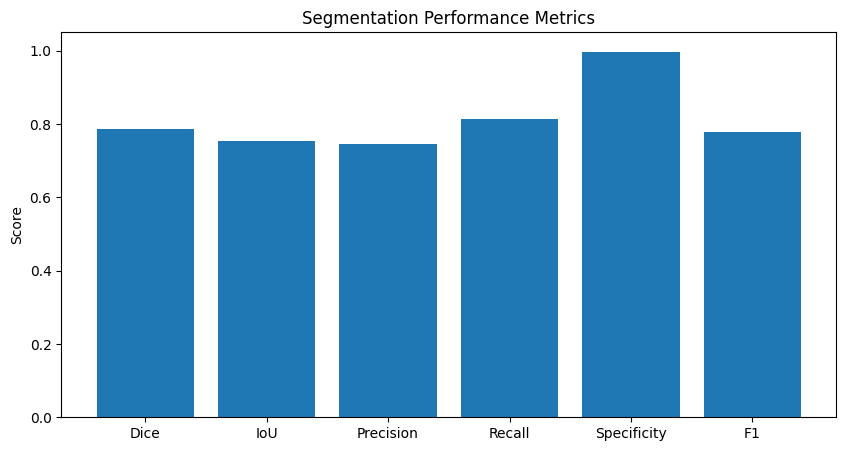

In [ ]:
import matplotlib.pyplot as plt

metrics = {
    "Dice":0.7850,
    "IoU":0.7526,
    "Precision":0.7450,
    "Recall":0.8124,
    "Specificity":0.9970,
    "F1":0.7773
}

plt.figure(figsize=(10,5))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0,1.05)
plt.title("Segmentation Performance Metrics")
plt.ylabel("Score")
plt.show()

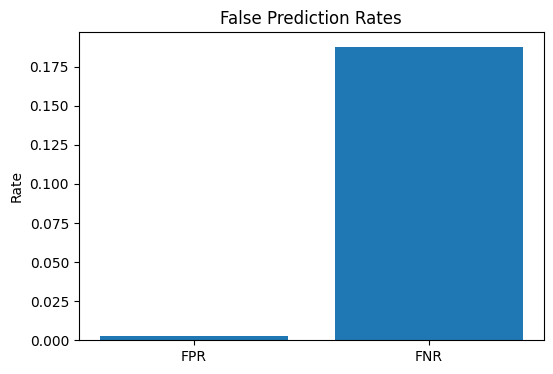

In [ ]:
errors = {
    "FPR":0.0030,
    "FNR":0.1876
}

plt.figure(figsize=(6,4))
plt.bar(errors.keys(), errors.values())
plt.title("False Prediction Rates")
plt.ylabel("Rate")
plt.show()

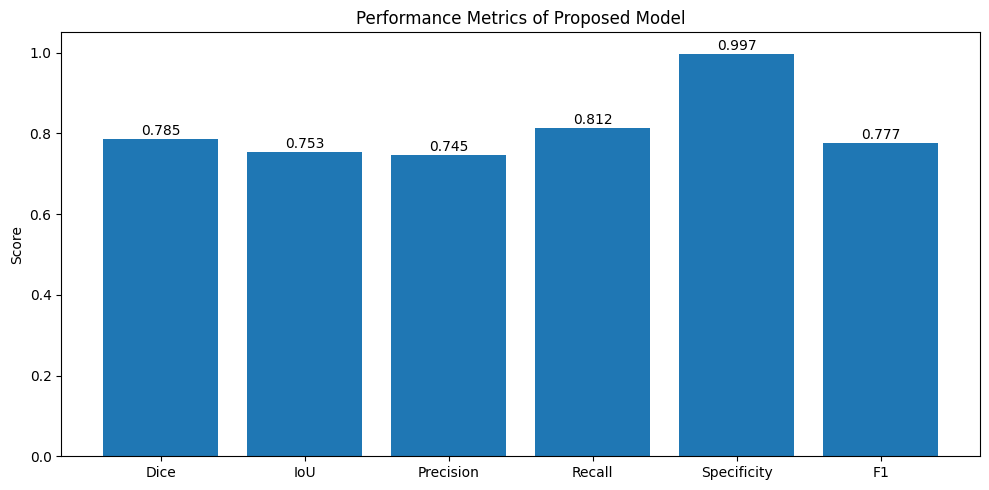

In [ ]:
import matplotlib.pyplot as plt

names = ["Dice","IoU","Precision","Recall","Specificity","F1"]
vals  = [0.785,0.753,0.745,0.812,0.997,0.777]

plt.figure(figsize=(10,5))
bars = plt.bar(names, vals)

plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("Performance Metrics of Proposed Model")

for bar, v in zip(bars, vals):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.3f}",
             ha='center', fontsize=10)

plt.tight_layout()
plt.show()

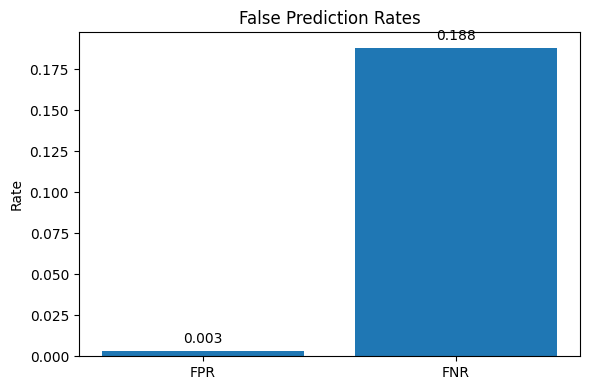

In [ ]:
errors = ["FPR","FNR"]
vals = [0.003,0.188]

plt.figure(figsize=(6,4))
bars = plt.bar(errors, vals)

plt.ylabel("Rate")
plt.title("False Prediction Rates")

for bar, v in zip(bars, vals):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.005, f"{v:.3f}",
             ha='center')

plt.tight_layout()
plt.show()

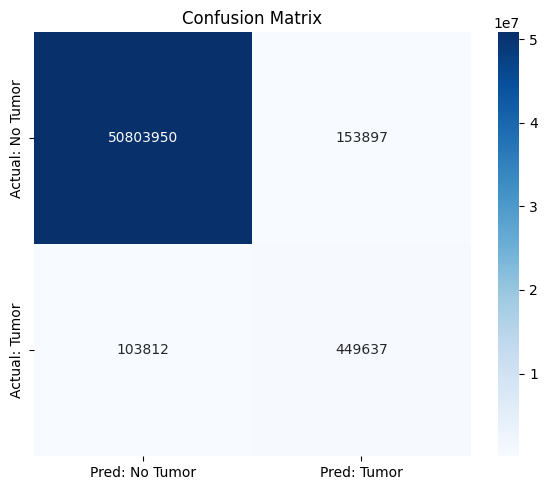

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cm = np.array([
    [50803950, 153897],   # TN, FP
    [103812,   449637]    # FN, TP
])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Pred: No Tumor","Pred: Tumor"],
    yticklabels=["Actual: No Tumor","Actual: Tumor"]
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming all_probs and all_targets collected earlier
fpr, tpr, _ = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'all_targets' is not defined

In [ ]:
from sklearn.metrics import roc_curve, auc

all_probs = []
all_targets = []

model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        # Flatten the arrays to work with roc_curve
        all_probs.extend(outputs.cpu().numpy().flatten())
        all_targets.extend(masks.cpu().numpy().flatten())

# Convert to numpy arrays for sklearn
all_probs = np.array(all_probs)
all_targets = np.array(all_targets)

print("Data collected. Now you can run the ROC curve cell.")

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming all_probs and all_targets collected earlier
fpr, tpr, _ = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()